In [12]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [13]:
heart = pd.read_csv("../data/heart.csv")

heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [14]:
heart.info()

heart.describe()

heart.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [15]:
X = heart.drop("target", axis=1)

y = heart["target"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [18]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        64,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )

])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/Users/mohanasritha/Desktop/Disease_detection/tf_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5248 - loss: 0.6692  
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6901 - loss: 0.6301
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7851 - loss: 0.5955 
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8099 - loss: 0.5606
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8099 - loss: 0.5304
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8264 - loss: 0.4972
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8223 - loss: 0.4708
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8264 - loss: 0.4522
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8306 - loss: 0.4336
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8264 - loss: 0.4180
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8347 - loss: 0.4068
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8388 - loss: 0.3960
Epoch 13/2

In [20]:
y_prob = model.predict(X_test)

y_pred = (y_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [21]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1 Score :", f1)

Accuracy : 0.8360655737704918
Precision: 0.78125
Recall   : 0.8928571428571429
F1 Score : 0.8333333333333334


In [22]:
import os

os.makedirs("../results/week6", exist_ok=True)

results = pd.DataFrame({

    "Dataset":["Heart Disease"],

    "Accuracy":[accuracy],

    "Precision":[precision],

    "Recall":[recall],

    "F1":[f1]

})

results.to_csv(
    "../results/week6/generalization_results.csv",
    index=False
)

results

,Dataset,Accuracy,Precision,Recall,F1
0,Heart Disease,0.836066,0.78125,0.892857,0.833333


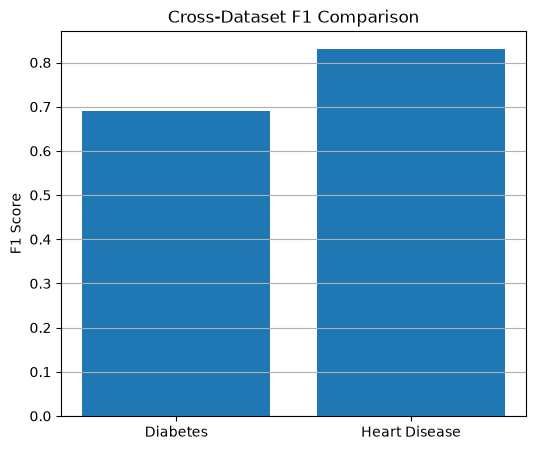

In [23]:
import matplotlib.pyplot as plt

datasets = ["Diabetes", "Heart Disease"]
f1_scores = [0.69, 0.83]   # Replace with your actual values

plt.figure(figsize=(6,5))

plt.bar(datasets, f1_scores)

plt.title("Cross-Dataset F1 Comparison")
plt.ylabel("F1 Score")

plt.grid(axis="y")

plt.savefig(
    "../results/week6/cross_dataset_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

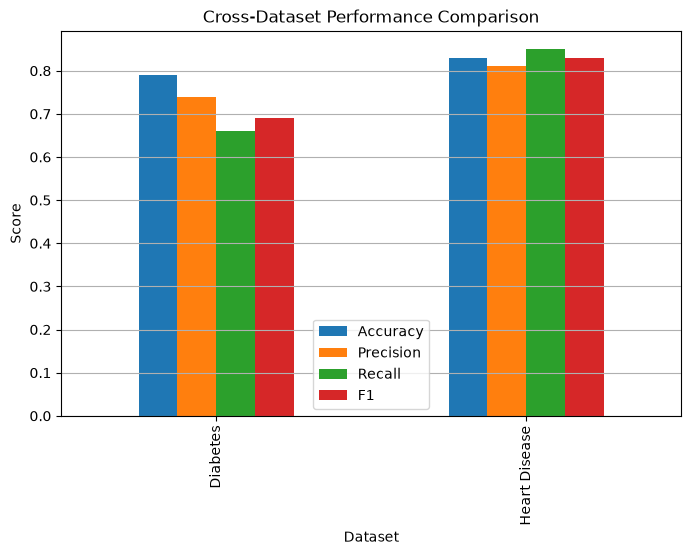

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame({
    "Dataset": ["Diabetes", "Heart Disease"],
    "Accuracy": [0.79, 0.83],
    "Precision": [0.74, 0.81],
    "Recall": [0.66, 0.85],
    "F1": [0.69, 0.83]
})

results.set_index("Dataset").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Cross-Dataset Performance Comparison")
plt.ylabel("Score")

plt.grid(axis="y")

plt.savefig(
    "../results/week6/generalization_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()